# Bagging (Bootstrap Aggregating) for Regression

Bagging is a method that reduces overfitting by training multiple models on different randomly-selected versions of the training data and averaging their predictions, a simple but powerful method to seperate signal from noise.

In this notebook, we'll:

1. Observe how a single decision tree can overfit to training data
2. Understand bootstrap sampling and out-of-bag samples
3. Build a bagged ensemble of decision trees
4. Compare the performance of a single tree vs. bagged ensemble on both clean and noisy data

Let's start by generating a noisy sin curve:


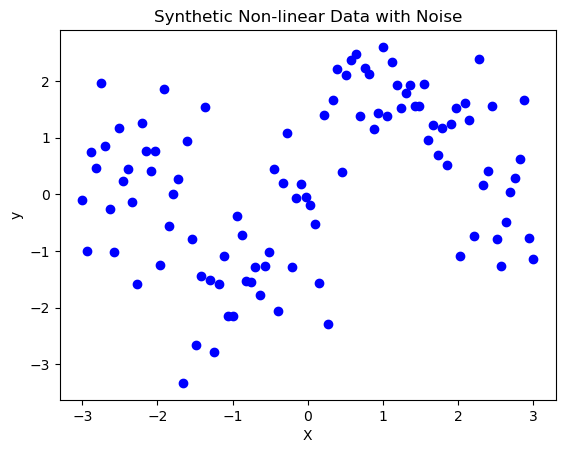

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(2026)

# # Synthetic non-linear data with lots of noise
X = np.linspace(-3, 3, 100)
y = np.sin(X) + np.sin(2*X) + np.random.normal(0.2, 1, X.shape)

# Plot
plt.scatter(X, y, color='blue', label='Data points')
plt.title('Synthetic Non-linear Data with Noise')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

We'll train a single decision tree with no depth limit and generate some predictions. Notice how the predictions follows every data point closely - this is overfitting. The tree has memorized the training data, including the noise, rather than learning the underlying sine pattern.

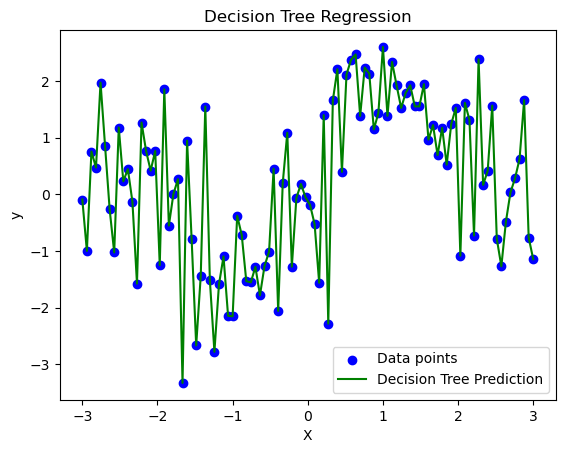

In [17]:
# Train decision tree regressor
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor(max_depth=None)
tree_reg.fit(X.reshape(-1, 1), y)
y_tree_pred = tree_reg.predict(X.reshape(-1, 1))

# Plot predictions
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, y_tree_pred, color='green', label='Decision Tree Prediction')
plt.title('Decision Tree Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

We can use bagging to reduce this overfitting, a method that combines:
- using random selection with replacement to create a version of the original data (called Bootstrap Sampling)
- creating N of these bootstrap samples, training N decision trees on each, and averaging their predictions

This produces predictions closer to the true underlying sine function:

Average % of out-of-bag samples in 100 trees: 36.6%


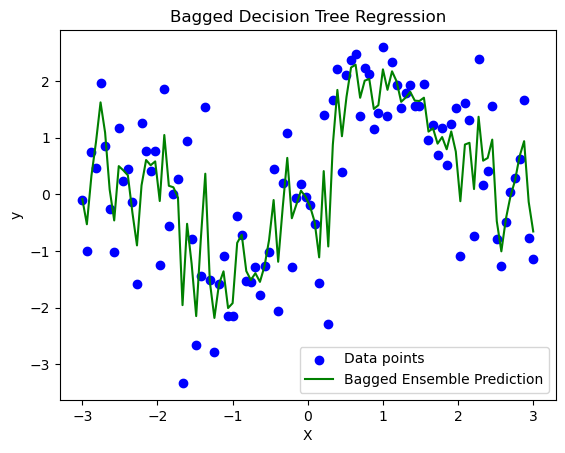

In [18]:
# Bootstrap sampling function
def bootstrap_sample(X, y):
    n_samples = X.shape[0]
    indices = np.random.randint(0, n_samples, n_samples) # Sample with replacement
    prop_samples_out_of_bag = len(set(range(n_samples)) - set(indices)) / n_samples
    return X[indices], y[indices], prop_samples_out_of_bag

# Train bagged ensemble of decision trees
n_trees = 100
oob_props = []
y_pred_ensemble = np.zeros((n_trees, X.shape[0]))
for i in range(n_trees):
    X_sample, y_sample, prop_samples_out_of_bag = bootstrap_sample(X.reshape(-1, 1), y)
    oob_props.append(prop_samples_out_of_bag)
    tree = DecisionTreeRegressor(max_depth=None)
    tree.fit(X_sample, y_sample)
    y_pred_ensemble[i] = tree.predict(X.reshape(-1, 1))

y_ensemble_pred = np.mean(y_pred_ensemble, axis=0)
print(f'Average % of out-of-bag samples in {n_trees} trees: {np.mean(oob_props) * 100:.1f}%')

# Plot ensemble predictions
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, y_ensemble_pred, color='green', label='Bagged Ensemble Prediction')
plt.title('Bagged Decision Tree Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

To quantify the value of this method, let's compare the performance of a single Decision Tree and Bagging on clean data. We'll measure the Mean Squared Error (MSE) between the predictions and the true underlying function. The bagged ensemble should have lower error because it averages out the overfitting of individual trees.

In [19]:
# Create pure sin data
X_pure = np.linspace(-3, 3, 100)
y_pure = np.sin(X_pure) + np.sin(2*X_pure)

# Train bagging regressor
from sklearn.ensemble import BaggingRegressor

bagging_regressor = BaggingRegressor(n_estimators=100, random_state=2026)
bagging_regressor.fit(X.reshape(-1, 1), y)

# Compare DecisionTreeRegressor and BaggingRegressor error
from sklearn.metrics import mean_squared_error

# Calculate MSE for both models
mse_dt = mean_squared_error(y_pure, tree_reg.predict(X_pure.reshape(-1, 1)))
mse_bagging = mean_squared_error(y_pure, bagging_regressor.predict(X_pure.reshape(-1, 1)))

print(f"Decision Tree MSE: {mse_dt:.4f}")
print(f"Bagging Regressor MSE: {mse_bagging:.4f}")



Decision Tree MSE: 1.0765
Bagging Regressor MSE: 0.4454


Now let's test on noisy data to see how both models handle unseen noise. The bagged ensemble should still outperform the single tree.

In [20]:
# Create noisy sin data
X_noisy = np.linspace(-3, 3, 100)
y_noisy = np.sin(X_noisy) + np.sin(2*X_noisy) + np.random.normal(0.2, 1, X.shape)

# Calculate MSE for both models
mse_dt = mean_squared_error(y_noisy, tree_reg.predict(X_noisy.reshape(-1, 1)))
mse_bagging = mean_squared_error(y_noisy, bagging_regressor.predict(X_noisy.reshape(-1, 1)))

print(f"Decision Tree MSE: {mse_dt:.4f}")
print(f"Bagging Regressor MSE: {mse_bagging:.4f}")



Decision Tree MSE: 1.8206
Bagging Regressor MSE: 1.2198


So what did we learn?

1. **Single Trees Overfit:** Decision trees with no depth limit will memorize training data, including noise, leading to poor generalization.

2. **Bootstrap Sampling Creates Diversity:** By training each tree on a different bootstrap sample, we ensure that each tree sees slightly different data, creating diverse models/predictions.

3. **Averaging Reduces Variance:** When we average the predictions of multiple trees, we smooth out the overfitting. The errors of individual trees tend to cancel out, resulting in a more stable and accurate prediction.
